In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 加载数据集并输出“地区”为“黄浦”的数据的头部信息
data = pd.read_csv("各地区房屋挂牌数据.csv")
huangpu_data = data[data['地区'] == '黄浦']
print(huangpu_data.head())

         序号        id  城市  地区                                            链接  \
2250  30186  40658486  上海  黄浦  https://sh.5i5j.com/ershoufang/40658486.html   
2373  63626  43029355  上海  黄浦  https://sh.5i5j.com/ershoufang/43029355.html   
2520  11321  34890563  上海  黄浦  https://sh.5i5j.com/ershoufang/34890563.html   
2552  19848  38731578  上海  黄浦  https://sh.5i5j.com/ershoufang/38731578.html   
2657  39797  41599204  上海  黄浦  https://sh.5i5j.com/ershoufang/41599204.html   

                          名称        小区        楼层    房屋类型        面积  \
2250   内环内总价低！！！近日月光，好房，看房随时   打浦路303弄   低楼层/6层   1室1厅1卫   8.4 平米    
2373       房东诚意出售,看房找我,看房有钥匙   斜土路550弄   中楼层/6层   1室0厅1卫  11.3 平米    
2520  总价低，交通便利，没有高额税费，看房非常方便   瞿溪路907弄    顶层/6层   1室1厅1卫  13.6 平米    
2552     紧邻轨交！看房方便，配套完善！诚意出售     天柱山小区    底层/6层   1室1厅1卫  10.3 平米    
2657   看房方便，总价低，楼层适宜，朝南采光超好。  制造局路370弄   中楼层/7层   1室1厅1卫  14.6 平米    

                标签    朝向  装修风格     建成时间          看房时间    看房人数           发布时间  \
2250  近地铁，满五年，近公园，    北 

In [7]:
# 2. 计算“城市”为“上海”的每个地区的平均“单价(每平方米)”，并按照从高到低排序
shanghai_data = data[data['城市']== '上海']
avg_price_per_area = shanghai_data.groupby('地区')['单价(每平方米)'].mean().sort_values(ascending=False)
print(avg_price_per_area)

地区
黄浦    86509.800000
长宁    67826.567973
徐汇    66465.704737
静安    63622.809333
杨浦    61146.478000
虹口    58802.932857
普陀    57244.553429
浦东    55183.322268
宝山    49499.498333
闵行    48622.121024
嘉定    39650.524000
松江    35346.634609
青浦    29073.402500
金山    17389.000000
Name: 单价(每平方米), dtype: float64


C:\Users\Administrator\AppData\Roaming\Python\Python37\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 40644 (\N{CJK UNIFIED IDEOGRAPH-9EC4}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\AppData\Roaming\Python\Python37\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 28006 (\N{CJK UNIFIED IDEOGRAPH-6D66}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\AppData\Roaming\Python\Python37\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 22320 (\N{CJK UNIFIED IDEOGRAPH-5730}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\AppData\Roaming\Python\Python37\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 21306 (\N{CJK UNIFIED IDEOGRAPH-533A}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\AppData\Roaming\Python\Python37\site-packages\IPython\core\pylabt

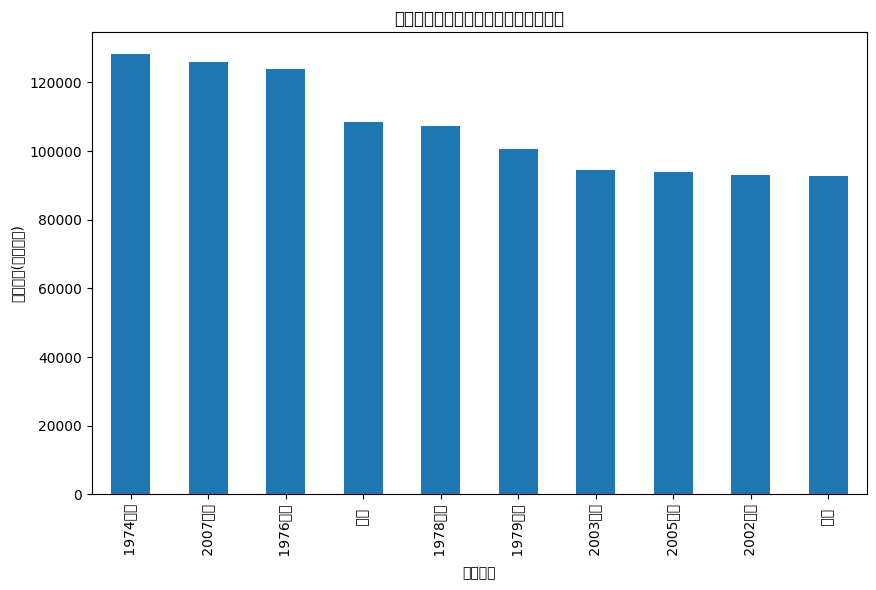

In [8]:
# 3. 计算“城市”为“上海”的所有地区中“单价(每平方米)”平均值最高的地区，同时分析该地区不同“装修风格”的平均单价分布
highest_avg_price_area = avg_price_per_area.idxmax()
highest_avg_price_area_data = shanghai_data[shanghai_data['地区'] == highest_avg_price_area]
avg_price_by_style = highest_avg_price_area_data.groupby("装修风格")["单价(每平方米)"].mean()

# 绘制柱状图
plt.figure(figsize=(10, 6))
avg_price_by_style.sort_values(ascending=False).head(10).plot(kind="bar")
plt.xlabel("装修风格")
plt.ylabel("平均单价(每平方米)")
plt.title(f"{highest_avg_price_area}地区不同装修风格的平均单价分布")
plt.show()